# Build api ais gfw dataset

**From this notebook you should get both italian and svn data**

In [2]:
import gfwapiclient as gfw
import pandas as pd 
import numpy as numpy
import os
import requests
import numpy as np
import matplotlib.pyplot as plt

# Set

In [3]:
# To set
year = 2025
temporal_granularity = 'DAILY'

start_month = '01'
start_day = '01'

end_month = '12'
end_day = '31'

start_date= f"{str(year)}-{start_month}-{start_day}"
end_date= f"{str(year)}-{end_month}-{end_day}" 
spatial_resolution= "HIGH" # LOW or MEDIUM or HIGH

product_name = "public-global-fishing-effort:latest"
#nation = 'ita' # ita = 5682, svn = 5692, hrv = 5673 AND 50167

lat_name = 'lat'
lon_name = 'lon'
lat_min = 45.4698
lat_max = 45.8078
lon_min = 13.141159647873394
lon_max = 13.8238

out_folder = 'data/raw/from_notebooks'
out_name = f'ais_{spatial_resolution.lower()}_{temporal_granularity.lower()}_ts_{str(year)}.parquet'

# Get data

In [7]:
with open("secrets/gfw_token.txt", "r") as token_file:
    TOKEN = token_file.read().strip()

gfw_client = gfw.Client(
    access_token=TOKEN
)

In [8]:
# BBOX Trieste (lon_min, lat_min, lon_max, lat_max)
bbox = (lon_min, lat_min, lon_max, lat_max)

# Costruisco un geojson Polygon dalla bbox
def bbox_to_geojson(lon_min, lat_min, lon_max, lat_max):
    return {
        "type": "Polygon",
        "coordinates": [[
            [lon_min, lat_min],
            [lon_max, lat_min],
            [lon_max, lat_max],
            [lon_min, lat_max],
            [lon_min, lat_min],
        ]]
    }

In [9]:
ais_report = await gfw_client.fourwings.create_report(
    datasets=[product_name],
    spatial_resolution="HIGH",        # più fine
    temporal_resolution="DAILY",      # più fine
    group_by="VESSEL_ID",             # per-nave
    spatial_aggregation=False,        # evita di aggregare su tutta l’area (se supportato)
    start_date=start_date,
    end_date=end_date,
    geojson=bbox_to_geojson(*bbox),   # AOI ristretto
    # filters=[ ... ]                 # opzionale: evita filtri restrittivi se vuoi “più dati”
)

In [10]:
df = ais_report.df()

In [11]:
df.shape[0]

7722

# Visualize 

In [12]:
gulf_df = pd.read_csv('data/raw/ts_gulf_coords.csv')

In [13]:
gfw_unq_coords = df.drop_duplicates(subset=[lat_name, lon_name]).copy()

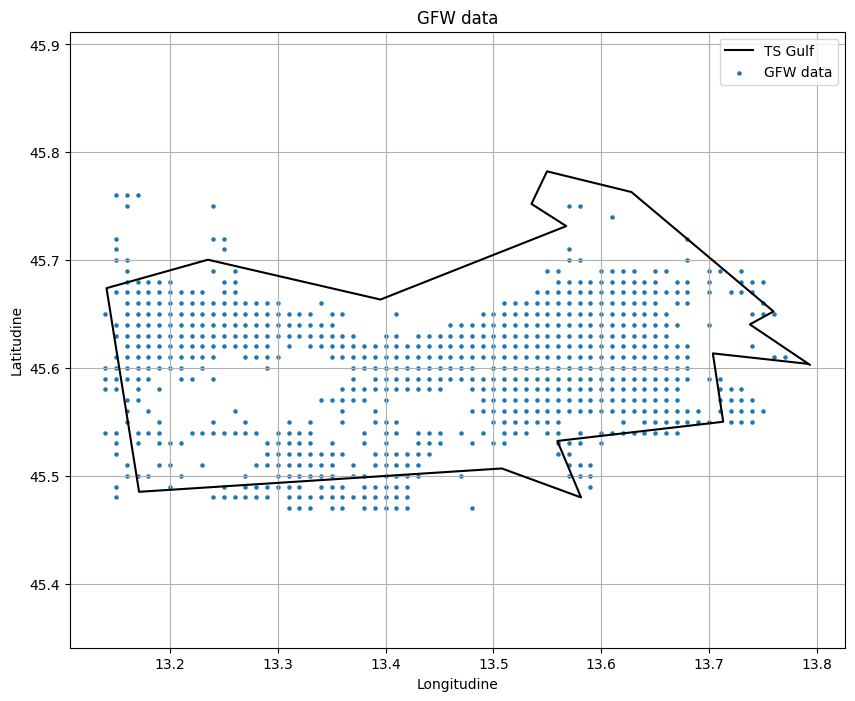

In [14]:
plt.figure(figsize=(10,8))

plt.plot(gulf_df['longitude'], gulf_df['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(gfw_unq_coords[lon_name], gfw_unq_coords[lat_name], label = 'GFW data', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.title("GFW data")

plt.show()

In [15]:
ita_df = df[df['flag'] == 'ITA'].copy() 
svn_df = df[df['flag'] == 'SVN'].copy()
hrv_df = df[df['flag'] == 'HRV'].copy()

ita_unq_coords = ita_df.drop_duplicates(subset=[lat_name, lon_name]).copy()
svn_unq_coords = svn_df.drop_duplicates(subset=[lat_name, lon_name]).copy()
hrv_unq_coords = hrv_df.drop_duplicates(subset=[lat_name, lon_name]).copy()

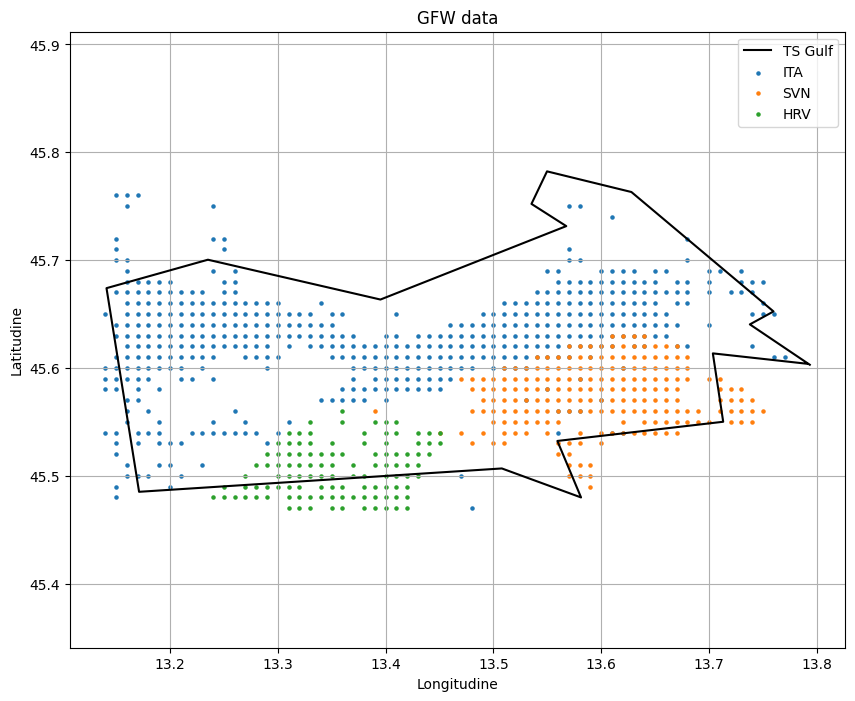

In [16]:
plt.figure(figsize=(10,8))

plt.plot(gulf_df['longitude'], gulf_df['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(ita_unq_coords[lon_name], ita_unq_coords[lat_name], label = 'ITA', s = 5)
plt.scatter(svn_unq_coords[lon_name], svn_unq_coords[lat_name], label = 'SVN', s = 5)
plt.scatter(hrv_unq_coords[lon_name], hrv_unq_coords[lat_name], label = 'HRV', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.title("GFW data")

plt.show()

# Export 

In [17]:
out = os.path.join(out_folder, out_name)
df.to_parquet(out, index=False)